<pre>
1. Download all the data in this folder https://drive.google.com/open?id=1Z4TyI7FcFVEx8qdl4jO9qxvxaqLSqoEu. it contains two file both images and labels. The label file list the images and their categories in the following format:
            <b>path/to/the/image.tif,category</b>
            
    where the categories are numbered 0 to 15, in the following order:

    <b>0 letter
    1 form
    2 email
    3 handwritten
    4 advertisement
    5 scientific report
    6 scientific publication
    7 specification
    8 file folder
    9 news article
    10 budget
    11 invoice
    12 presentation
    13 questionnaire
    14 resume
    15 memo</b>
    
2. On this image data, you have to train 3 types of models as given below. You have to split the data into Train and Validation data.

3. Try not to load all the images into memory, use the gernarators that we have given the reference notebooks to load the batch of images only during the train data.
or you can use this method also
<a href='https://medium.com/@vijayabhaskar96/tutorial-on-keras-imagedatagenerator-with-flow-from-dataframe-8bd5776e45c1'>https://medium.com/@vijayabhaskar96/tutorial-on-keras-imagedatagenerator-with-flow-from-dataframe-8bd5776e45c1</a>

<a href='https://medium.com/@vijayabhaskar96/tutorial-on-keras-flow-from-dataframe-1fd4493d237c'>https://medium.com/@vijayabhaskar96/tutorial-on-keras-flow-from-dataframe-1fd4493d237c</a>


4. You are free to choose Learning rate, optimizer, loss function, image augmentation, any hyperparameters. but you have to use the same architechture what we are asking below. 

5. Use tensorboard for every model and analyse your gradients. (you need to upload the screenshots for each model for evaluation)

Note: fit_genarator() method will have problems with the tensorboard histograms, try to debug it, if you could not do use histgrams=0 i.e don't include histograms, check the documentation of tensorboard for more information. 

6. You can check about Transfer Learning in this link - <a href='https://blog.keras.io/building-powerful-image-classification-models-using-very-little-data.html'>https://blog.keras.io/building-powerful-image-classification-models-using-very-little-data.html</a>
</pre>

In [0]:
!pip install pyunpack
!pip install patool

In [3]:
import os
import cv2
import pandas as pd
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from  pyunpack import Archive
import keras
from sklearn.model_selection import train_test_split
from sklearn.model_selection import StratifiedKFold 
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, ZeroPadding2D
from keras.layers import Activation,Dropout, Flatten, Dense,Input
from keras.models import Model
from keras import applications
from keras.preprocessing.image import ImageDataGenerator
from keras import backend as K
import datetime

Using TensorFlow backend.


In [0]:
!wget --header="Host: doc-08-9c-docs.googleusercontent.com" --header="User-Agent: Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/83.0.4103.61 Safari/537.36" --header="Accept: text/html,application/xhtml+xml,application/xml;q=0.9,image/webp,image/apng,*/*;q=0.8,application/signed-exchange;v=b3;q=0.9" --header="Accept-Language: en-US,en;q=0.9" --header="Referer: https://drive.google.com/drive/folders/1eY4pTqtGtXSAYVzaHwWAK2Cq4bHb1Zkq" --header="Cookie: AUTH_50d5apvko044gdv7g4ngngaf3k2a4u8s_nonce=8nltjnvr2kmjq" --header="Connection: keep-alive" "https://doc-08-9c-docs.googleusercontent.com/docs/securesc/fb7tkcqtdeao6376srhf0vlq2q1kj22u/e9l3krf1pmeaq6gupob0dpsq1u4idmq6/1591935825000/00484516897554883881/09618707971293681707/1Z4TyI7FcFVEx8qdl4jO9qxvxaqLSqoEu?e=download&authuser=0&nonce=8nltjnvr2kmjq&user=09618707971293681707&hash=fc0if0mv9n4pqiqt3lf0ej38qjc8s95u" -c -O 'rvl-cdip.rar'

--2020-06-12 04:27:03--  https://doc-08-9c-docs.googleusercontent.com/docs/securesc/fb7tkcqtdeao6376srhf0vlq2q1kj22u/e9l3krf1pmeaq6gupob0dpsq1u4idmq6/1591935825000/00484516897554883881/09618707971293681707/1Z4TyI7FcFVEx8qdl4jO9qxvxaqLSqoEu?e=download&authuser=0&nonce=8nltjnvr2kmjq&user=09618707971293681707&hash=fc0if0mv9n4pqiqt3lf0ej38qjc8s95u
Resolving doc-08-9c-docs.googleusercontent.com (doc-08-9c-docs.googleusercontent.com)... 108.177.125.132, 2404:6800:4008:c01::84
Connecting to doc-08-9c-docs.googleusercontent.com (doc-08-9c-docs.googleusercontent.com)|108.177.125.132|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [application/rar]
Saving to: ‘rvl-cdip.rar’

rvl-cdip.rar            [ <=>                ]   4.34G  27.7MB/s    in 86s     

2020-06-12 04:28:30 (51.7 MB/s) - ‘rvl-cdip.rar’ saved [4660541790]



In [0]:
! ls

rvl-cdip.rar  sample_data


In [0]:
Archive('rvl-cdip.rar').extractall('/content/')

In [0]:
dir_path = "/content/data_final"

In [0]:
label= pd.read_csv('labels_final.csv')
label.head()

,path,label
0,imagesv/v/o/h/voh71d00/509132755+-2755.tif,3
1,imagesl/l/x/t/lxt19d00/502213303.tif,3
2,imagesx/x/e/d/xed05a00/2075325674.tif,2
3,imageso/o/j/b/ojb60d00/517511301+-1301.tif,3
4,imagesq/q/z/k/qzk17e00/2031320195.tif,7


In [0]:
#refered from this link:   https://studymachinelearning.com/keras-imagedatagenerator-with-flow_from_dataframe/
batch_size =48
train_datagen = ImageDataGenerator(
        rescale=1 / 255.0,
        rotation_range=20,
        zoom_range=0.05,
        width_shift_range=0.05,
        height_shift_range=0.05,
        shear_range=0.05,
        horizontal_flip=True,
        fill_mode="nearest",
        validation_split=0.20)


train_generator = train_datagen.flow_from_dataframe(
    dataframe=label,
    directory=dir_path,
    x_col="path",
    y_col="label",
    target_size=(400  , 400),
    batch_size=batch_size,
    class_mode="raw",
    subset='training',
    shuffle=True,
    seed=42
)

valid_generator = train_datagen.flow_from_dataframe(
    dataframe=label,
    directory=dir_path,
    x_col="path",
    y_col="label",
    target_size=(400 , 400),
    batch_size=batch_size,
    class_mode="raw",
    subset='validation',
    shuffle=True,
    seed=42
)

Found 38400 validated image filenames.
Found 9600 validated image filenames.


<class 'numpy.ndarray'>
(48, 400, 400, 3)
[ 9 11  8  8  4  3  0  1  2  7  0  6 13  7  7 15  2 14  6  6  2  7 10  6
 10  1 13  7 13  8 11 10  7 13  8  1  5 10  6 14 15  2 10  0  0 12 15  2]


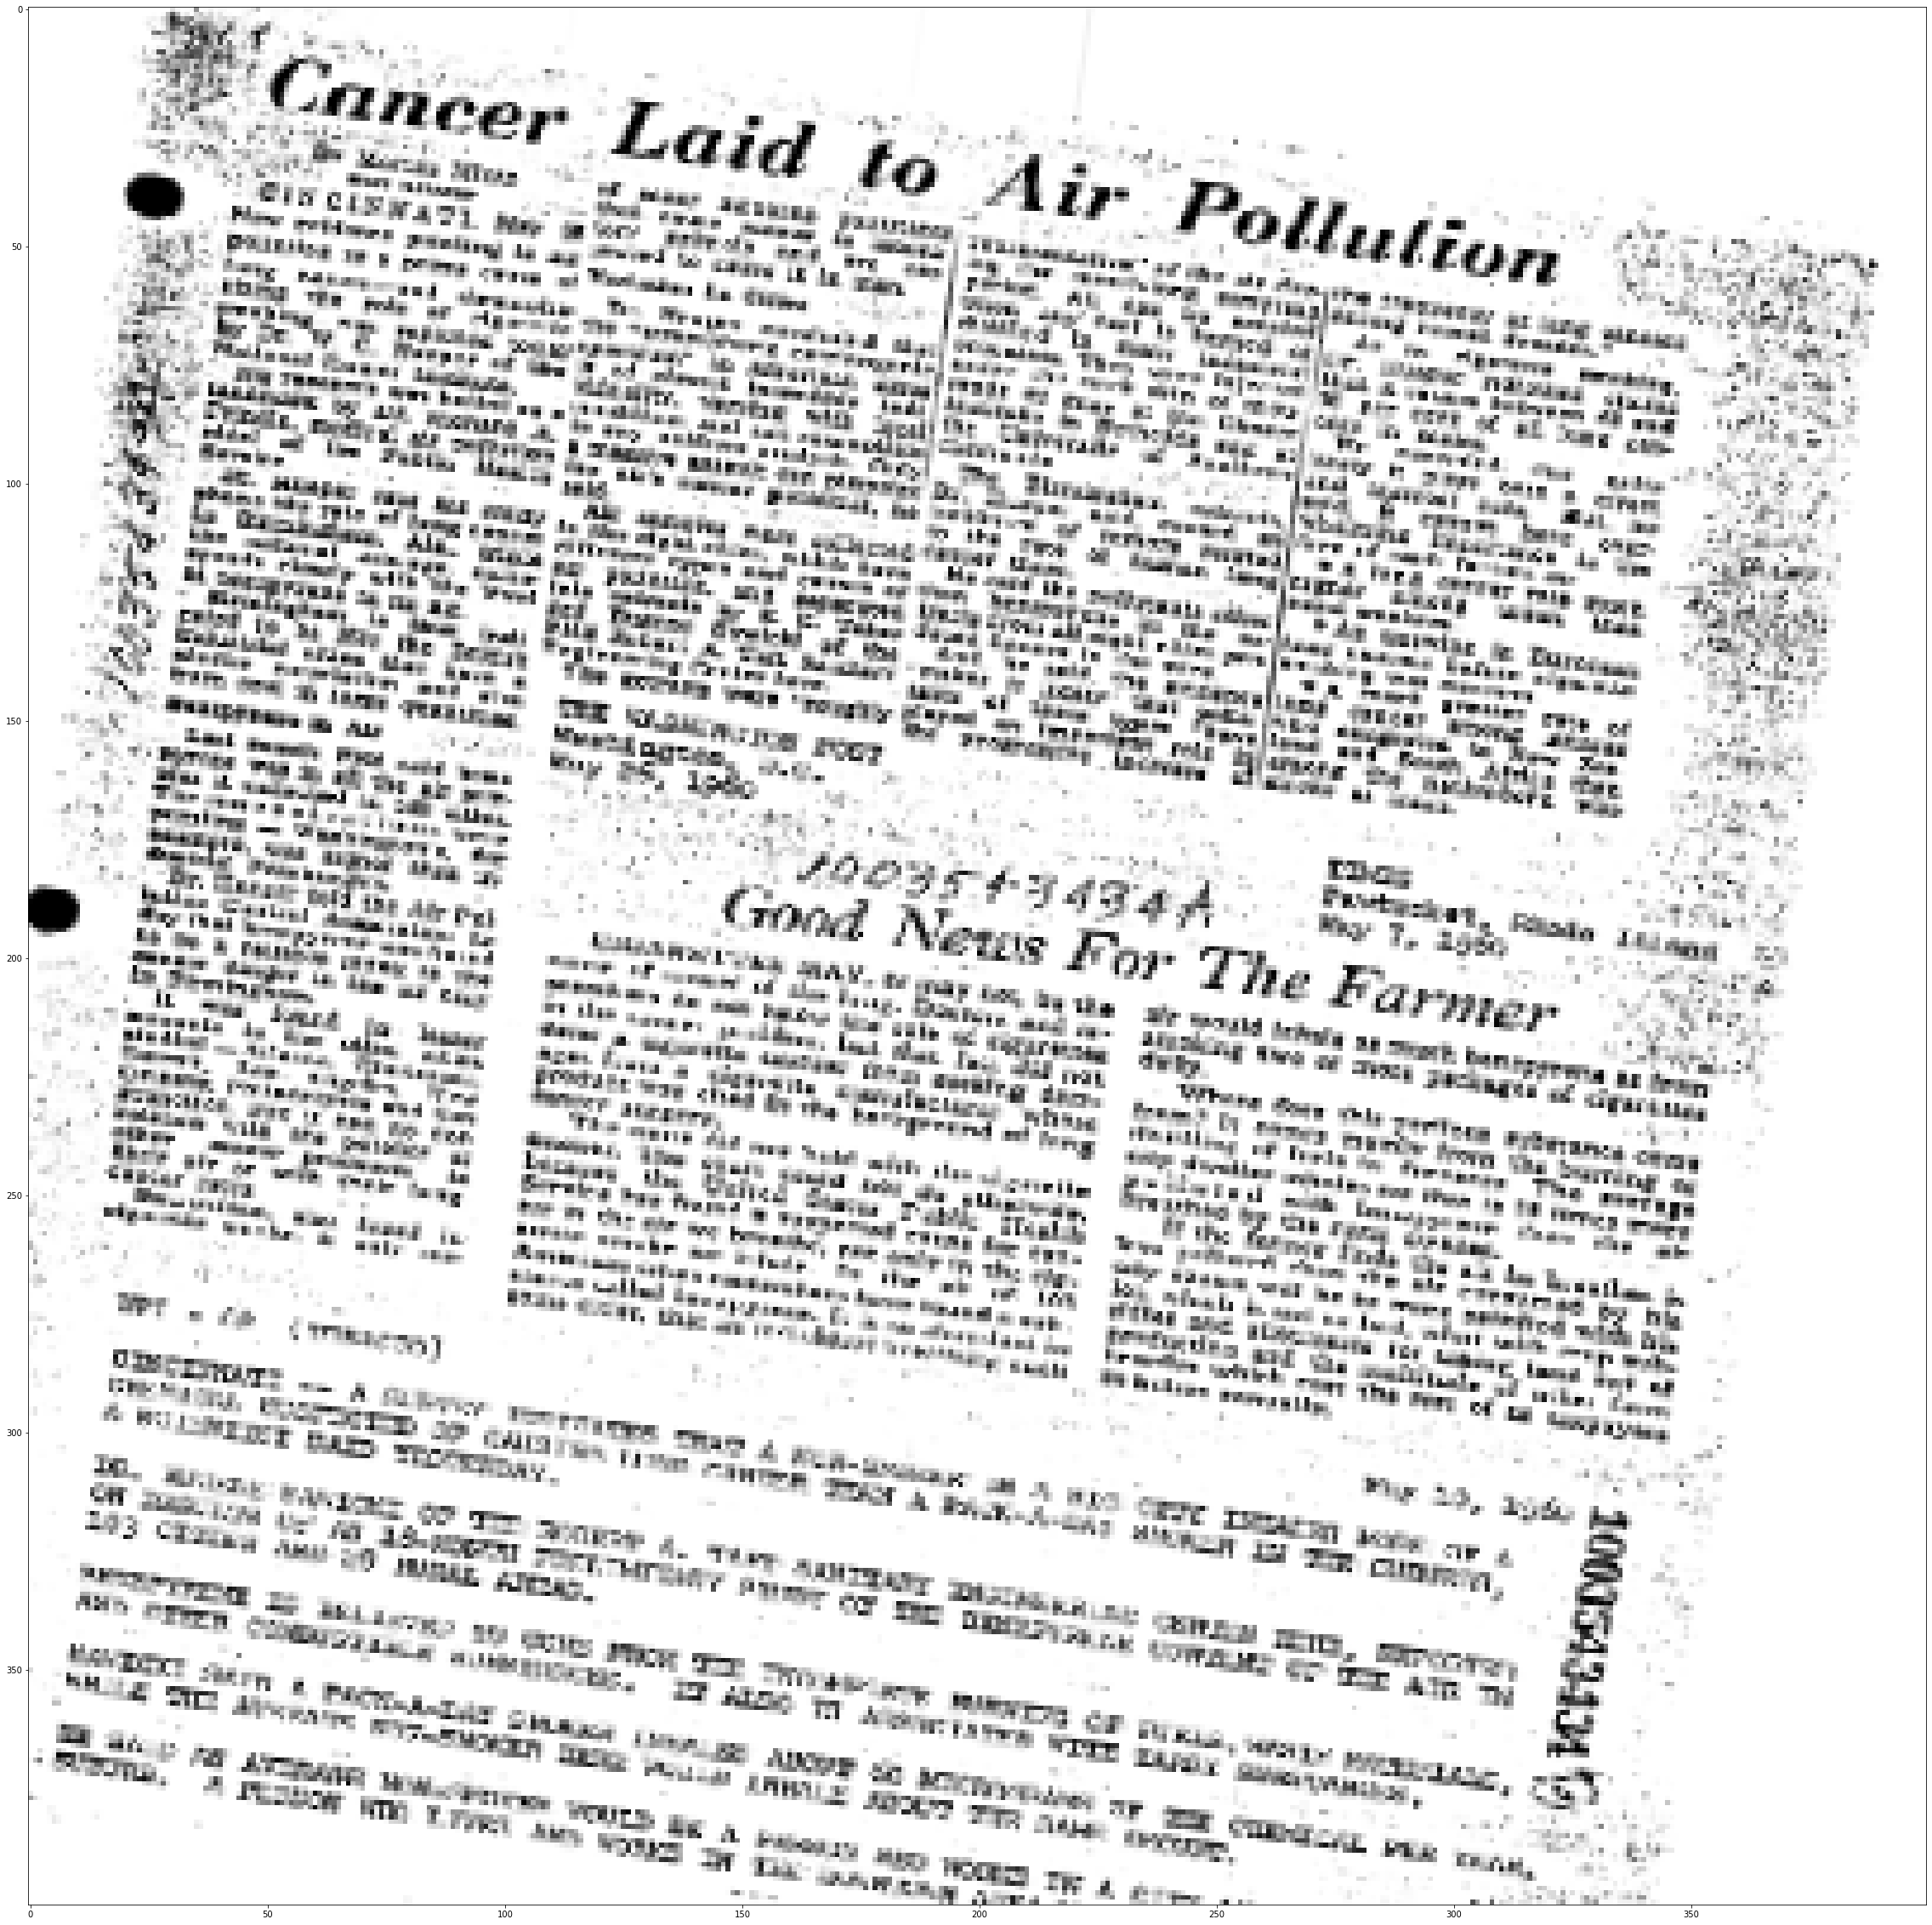

In [0]:
batches = 0
per_batch = 32
for x_batch, y_batch in train_generator:
  print(type(x_batch))
  print(x_batch.shape)
  plt.figure(figsize=(40,70))
  plt.imshow(x_batch[0])
  print(y_batch)
  batches += 1
  if batches ==1:
    break 

In [0]:
tf.keras.backend.clear_session()

In [0]:
%load_ext tensorboard
%tensorboard --logdir $log_dir

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


Reusing TensorBoard on port 6007 (pid 1291), started 0:01:06 ago. (Use '!kill 1291' to kill it.)

<IPython.core.display.Javascript object>

### Model-1

<pre>
1. Use <a href='https://www.tensorflow.org/api_docs/python/tf/keras/applications/VGG16'>VGG-16</a> pretrained network without Fully Connected layers and initilize all the weights with Imagenet trained weights. 
2. After VGG-16 network without FC layers, add a new Conv block ( 1 Conv layer and 1 Maxpooling ), 2 FC layers and a output layer to classify 16 classes. You are free to choose any hyperparameters/parameters of conv block, FC layers, output layer. 
3. Final architecture will be <b>INPUT --> VGG-16 without Top layers(FC) --> Conv Layer --> Maxpool Layer --> 2 FC layers --> Output Layer</b>
4. Train only new Conv block, FC layers, output layer. Don't train the VGG-16 network. 

</pre>

In [0]:
log_dir= os.path.join("logs",datetime.datetime.now().strftime("%Y%m%d-%H%M%S")) #Log directory for tensorboard
tensorboard_callback = keras.callbacks.TensorBoard(log_dir=log_dir,histogram_freq=1, write_graph=True,write_grads=True)

/usr/local/lib/python3.6/dist-packages/keras/callbacks/tensorboard_v2.py:97: UserWarning: The TensorBoard callback does not support gradients display when using TensorFlow 2.0. The `write_grads` argument is ignored.
  warnings.warn('The TensorBoard callback does not support '


In [0]:
keras.backend.clear_session()
!rm -rf ./logs/ 
nb_train_samples= 38400
nb_validation_samples=9600
batch_size=48
input_tensor = Input(shape=(400,400,3))

base_model = applications.VGG16(weights='imagenet', include_top=False,input_tensor=input_tensor)
x= base_model.output #Inputting output of base model
# build a classifier model to put on top of the convolutional model
x = Conv2D(64, (3, 3), activation='relu')    (x)
x = MaxPooling2D((2,2), strides=(2,2))       (x)
x = Flatten()                                (x)
x = Dense(128, activation='relu')            (x)
x = Dense(64, activation='relu')             (x)
predictions = Dense(16, activation='softmax')(x)
model1 = Model(inputs=base_model.input, outputs=predictions)

for layer in base_model.layers:
  layer.trainable = False
model1.compile(optimizer='rmsprop',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

model1.fit_generator(
    train_generator,
    steps_per_epoch=nb_train_samples//batch_size,
    epochs=3,
    callbacks = [tensorboard_callback],
    validation_data=valid_generator,
    validation_steps=nb_validation_samples//batch_size)

Epoch 1/3
800/800 [==============================] - 1928s 2s/step - loss: 1.5182 - accuracy: 0.5286 - val_loss: 1.3693 - val_accuracy: 0.6172
Epoch 2/3
800/800 [==============================] - 1887s 2s/step - loss: 1.1533 - accuracy: 0.6523 - val_loss: 1.0671 - val_accuracy: 0.6687
Epoch 3/3
800/800 [==============================] - 1916s 2s/step - loss: 1.0432 - accuracy: 0.6824 - val_loss: 1.3415 - val_accuracy: 0.6934


Observation Model1
1.   Final validation accuracy of model1 is 69.34
2.   The model uses imagenet weights which were set as no trainable in this model.
1.   The model perform decently with extra addition of just one Conv, one Maxpool and three dense layers.
2.   As we increase input shape from (400,400) to higher size, model accuracy further improves.
1.   Val accuracy is starting after training accuracy and in the next epoch training accuracy is starting after Val accuracy of first epoch.









58892288/58889256 [==============================] - 42s 1us/step


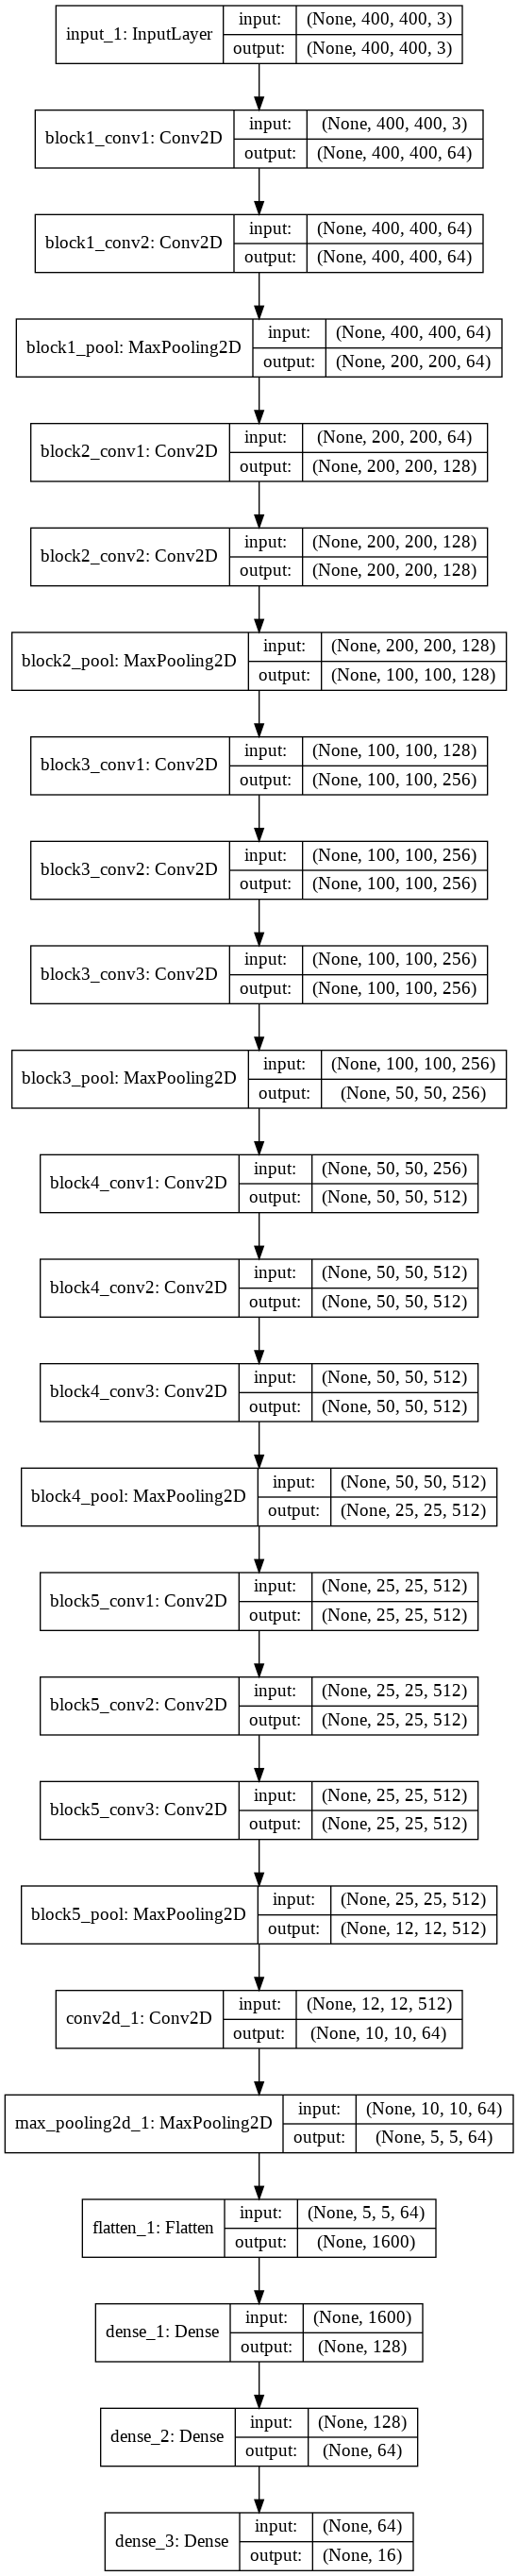

In [4]:
#plot of Model1
keras.utils.plot_model(model1, 'model1_transfer_learning.png', show_shapes=True)


### Model-2

<pre>
1. Use <a href='https://www.tensorflow.org/api_docs/python/tf/keras/applications/VGG16'>VGG-16</a> pretrained network without Fully Connected layers and initilize all the weights with Imagenet trained weights.
2. After VGG-16 network without FC layers, don't use FC layers, use conv layers only as Fully connected layer. any FC layer can be converted to a CONV layer. This conversion will reduce the No of Trainable parameters in FC layers. For example, an FC layer with K=4096 that is looking at some input volume of size 7×7×512 can be equivalently expressed as a CONV layer with F=7,P=0,S=1,K=4096. In other words, we are setting the filter size to be exactly the size of the input volume, and hence the output will simply be 1×1×4096 since only a single depth column “fits” across the input volume, giving identical result as the initial FC layer. You can refer <a href='http://cs231n.github.io/convolutional-networks/#convert'>this</a> link to better understanding of using Conv layer in place of fully connected layers.
3. Final architecture will be VGG-16 without FC layers(without top), 2 Conv layers identical to FC layers, 1 output layer for 16 class classification. <b>INPUT --> VGG-16 without Top layers(FC) --> 2 Conv Layers identical to FC --> Output Layer</b>
3. Train only last 2 Conv layers identical to FC layers, 1 output layer. Don't train the VGG-16 network. 
</pre>

In [0]:
tf.keras.backend.clear_session()
!rm -rf ./logs/ 
nb_train_samples= 38400
nb_validation_samples=9600
batch_size=48
input_tensor = Input(shape=(400,400,3))

base_model = applications.VGG16(weights='imagenet', include_top=False,input_tensor=input_tensor)
x= base_model.output
# build a classifier model to put on top of the convolutional model
x = Conv2D(48, (1,1), activation='relu')      (x)
x = Conv2D(4096, (12,12), activation='relu')  (x)      
x = Flatten()                                 (x)              
predictions = Dense(16, activation='softmax') (x)
model2 = Model(inputs=base_model.input, outputs=predictions)

for layer in base_model.layers:
  layer.trainable = False
model2.compile(optimizer='rmsprop',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

model2.fit_generator(
    train_generator,
    steps_per_epoch=nb_train_samples//batch_size,
    callbacks = [tensorboard_callback],
    epochs=3,
    validation_data=valid_generator,
    validation_steps=nb_validation_samples//batch_size)


Epoch 1/3
800/800 [==============================] - 1959s 2s/step - loss: 1.7072 - accuracy: 0.5767 - val_loss: 0.8598 - val_accuracy: 0.6771
Epoch 2/3
800/800 [==============================] - 1954s 2s/step - loss: 1.0444 - accuracy: 0.6885 - val_loss: 0.9981 - val_accuracy: 0.7069
Epoch 3/3
800/800 [==============================] - 1937s 2s/step - loss: 0.9688 - accuracy: 0.7172 - val_loss: 0.9612 - val_accuracy: 0.6949


Observation Model2

1 Final validation accuracy of model2 is 69.49 whih is slight improvement over 
model1.

2 The model uses imagenet weights which were set as no trainable in this model.

3 The first Conv layer after imagenet layers has filter shape (1,1) which has reduced depth of layer from 512 to 48 thus reducing huge number of weights for next layer.

4 As we increase input shape from (400,400) to higher size, model accuracy further improves.

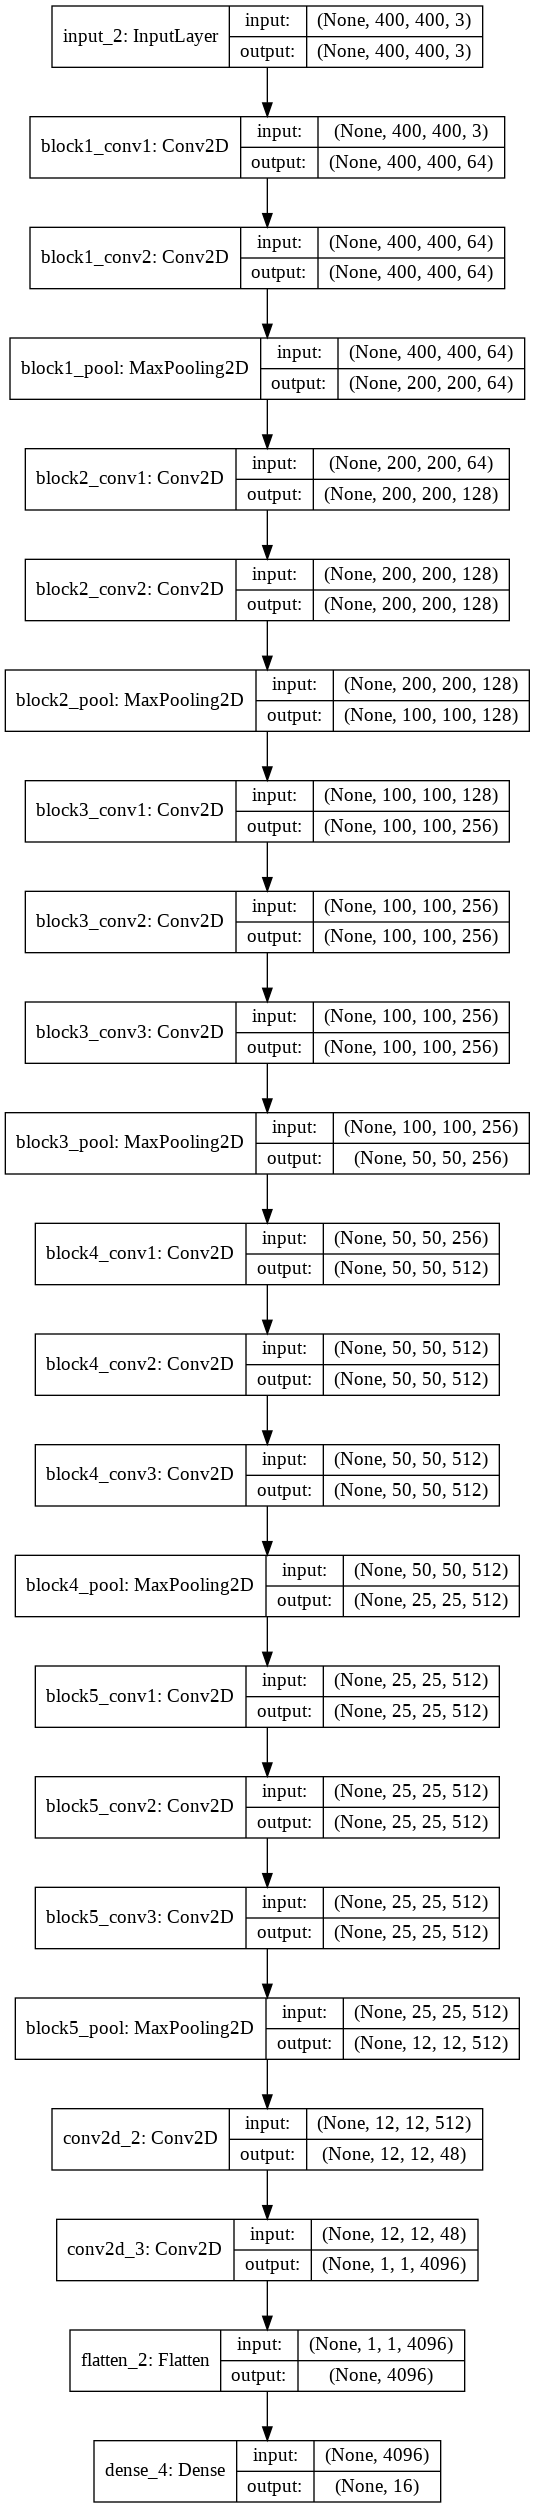

In [5]:
keras.utils.plot_model(model2, 'model2_transfer_learning.png', show_shapes=True)

### Model-3

<pre>
1. Use same network as Model-2 '<b>INPUT --> VGG-16 without Top layers(FC) --> 2 Conv Layers identical to FC --> Output Layer</b>' and train only Last 6 Layers of VGG-16 network, 2 Conv layers identical to FC layers, 1 output layer.
</pre>

In [0]:
tf.keras.backend.clear_session()
!rm -rf ./logs/ 
nb_train_samples= 38400
nb_validation_samples=9600
batch_size=48
input_tensor = Input(shape=(400,400,3))

base_model = applications.VGG16(weights='imagenet', include_top=False,input_tensor=input_tensor)
x= base_model.output
# build a classifier model to put on top of the convolutional model
x = Conv2D(48, (1, 1), activation='relu')     (x)
x = Conv2D(4096, (12, 12), activation='relu') (x)
x = Flatten()                                 (x) 
predictions = Dense(16, activation='softmax') (x)
model3 = Model(inputs=base_model.input, outputs=predictions)

for layer in base_model.layers:
  layer.trainable = False
for layer in base_model.layers[-6:]:
  layer.trainable = True

optimizer= keras.optimizers.Adagrad(learning_rate=0.001)

model3.compile(optimizer=optimizer,loss='sparse_categorical_crossentropy',metrics=['accuracy'])

model3.fit_generator(
    train_generator,
    steps_per_epoch=nb_train_samples//batch_size,
    epochs=3,
    callbacks = [tensorboard_callback],
    validation_data=valid_generator,
    validation_steps=nb_validation_samples//batch_size)

58892288/58889256 [==============================] - 5s 0us/step
Epoch 1/3
800/800 [==============================] - 2661s 3s/step - loss: 1.8931 - accuracy: 0.4101 - val_loss: 1.2912 - val_accuracy: 0.6016
Epoch 2/3
800/800 [==============================] - 2590s 3s/step - loss: 1.1484 - accuracy: 0.6528 - val_loss: 1.0280 - val_accuracy: 0.6839
Epoch 3/3
800/800 [==============================] - 2601s 3s/step - loss: 0.9560 - accuracy: 0.7094 - val_loss: 0.9836 - val_accuracy: 0.7084


Observation Model3

1 Final validation accuracy of model2 is 70.84 whih is again slight improvement over model1 and model2.

2 This model has last six layers of imagenet as trainable which has increased traing time to around 2600 seconds per epoch which was around 1950 second per epoch in model 1 and model2.

3 The first Conv layer after imagenet layers has filter shape (1,1) which has reduced depth of layer from 512 to 48 thus reducing huge number of weights for next layer.

4 As we increase input shape from (400,400) to higher size, model accuracy further improves.

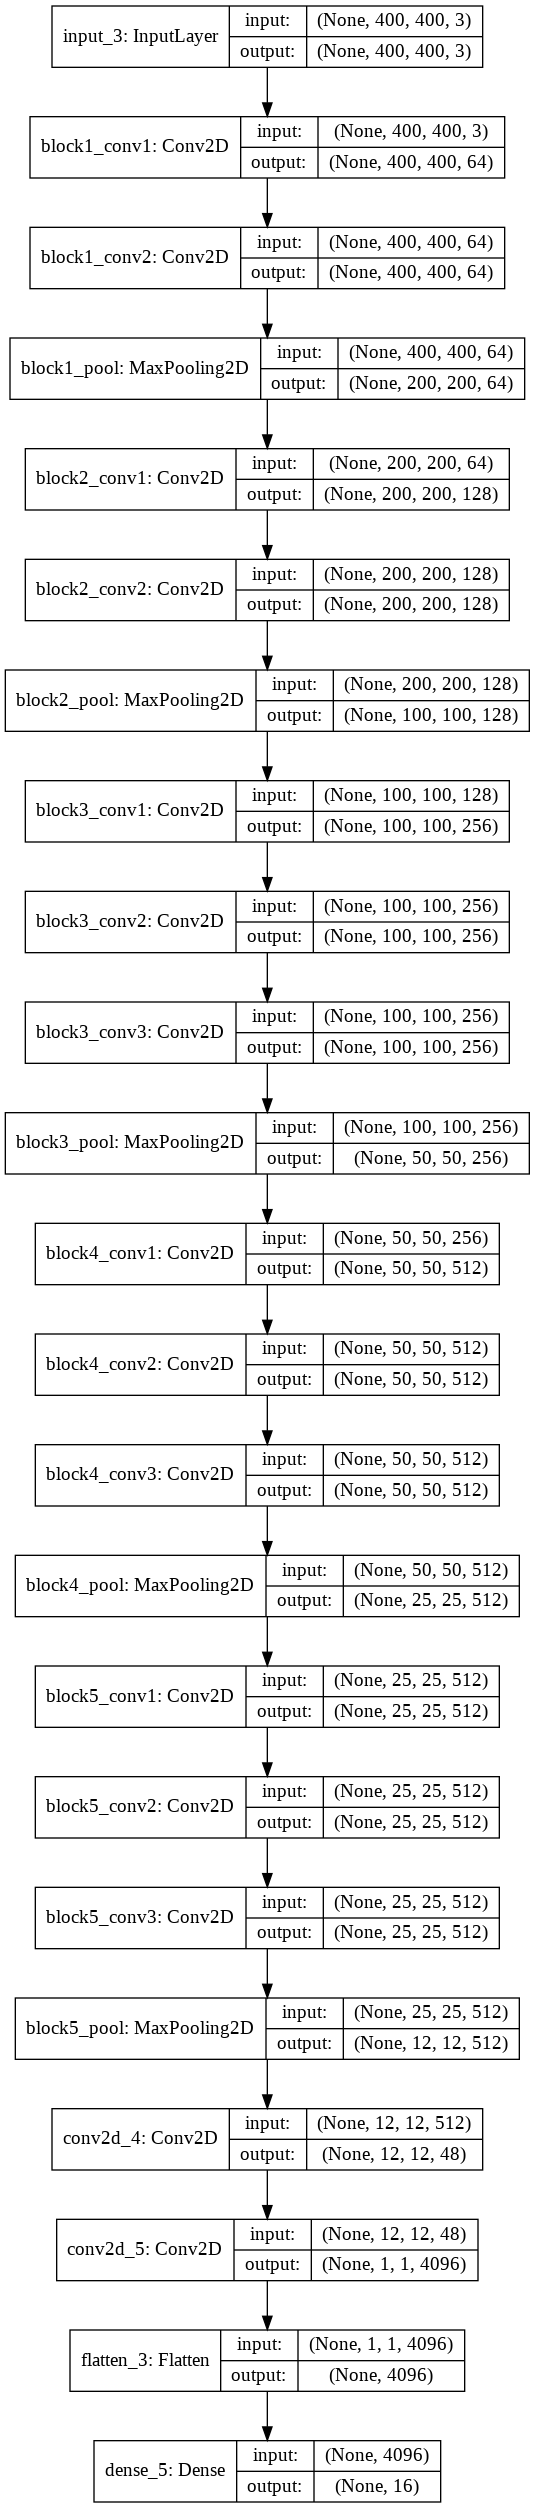

In [6]:
keras.utils.plot_model(model3, 'model3_transfer_learning.png', show_shapes=True)